# Country GDP Forecasting

Dataset: country-level annual GDP records (209 countries, 1960-2020).
Task: time-series regression, predict a country's `gdp` (log-transformed) using lag and rolling features.
Pipeline: data cleaning, EDA, leakage-safe feature engineering, model training, evaluation, optimization.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")
RANDOM_STATE = 42

## 1. Load Data

In [5]:
df = pd.read_csv("data/GDP.csv")
print(df.shape)
df.head()

(10134, 6)


,year,rank,country,state,gdp,gdp_percent
0,1960,1,the United States,America,543300000000,0.468483
1,1960,2,United Kingdom,Europe,73233967692,0.063149
2,1960,3,France,Europe,62225478000,0.053656
3,1960,4,China,Asia,59716467625,0.051493
4,1960,5,Japan,Asia,44307342950,0.038206


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10134 entries, 0 to 10133
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   year         10134 non-null  int64  
 1   rank         10134 non-null  int64  
 2   country      10134 non-null  str    
 3   state        10134 non-null  str    
 4   gdp          10134 non-null  int64  
 5   gdp_percent  10134 non-null  float64
dtypes: float64(1), int64(3), str(2)
memory usage: 475.2 KB


## 2. Data Cleaning

In [4]:
# data quality issue: the name 'Dominica' maps to two different countries in this
# dataset (GDP values for the same year differ by roughly 100x, e.g. 1977: $4.7B vs
# $36M), indicating a mislabeling collision, most likely with Dominican Republic.
# since the two cannot be reliably separated, all 'Dominica' rows are dropped.
print(df[df["country"] == "Dominica"].duplicated(subset=["year"]).sum(), "duplicate year rows for Dominica")
df = df[df["country"] != "Dominica"].reset_index(drop=True)

# confirm no other country-year duplicates remain
print("Remaining duplicate country-year pairs:", df.duplicated(subset=["year", "country"]).sum())

# sort chronologically within each country, required before building lag features
df = df.sort_values(["country", "year"]).reset_index(drop=True)
print(df.shape)

44 duplicate year rows for Dominica
Remaining duplicate country-year pairs: 0
(10029, 6)


## 3. Exploratory Data Analysis

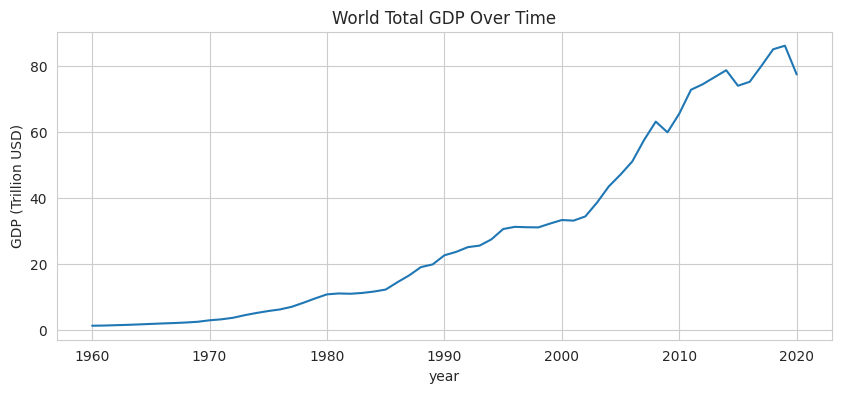

In [5]:
world_gdp = df.groupby("year")["gdp"].sum()
plt.figure(figsize=(10, 4))
(world_gdp / 1e12).plot()
plt.title("World Total GDP Over Time")
plt.ylabel("GDP (Trillion USD)")
plt.show()

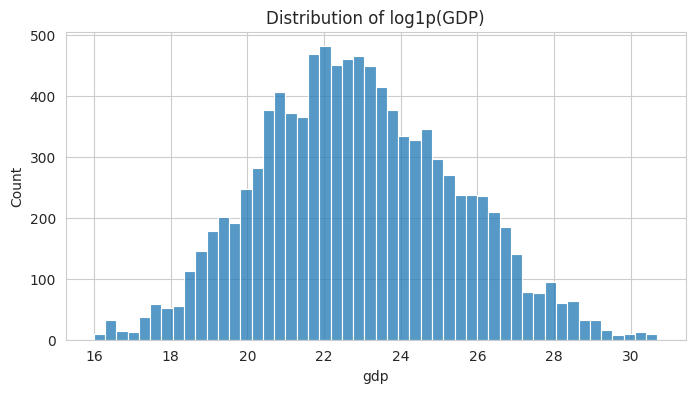

In [6]:
plt.figure(figsize=(8, 4))
sns.histplot(np.log1p(df["gdp"]), bins=50)
plt.title("Distribution of log1p(GDP)")
plt.show()

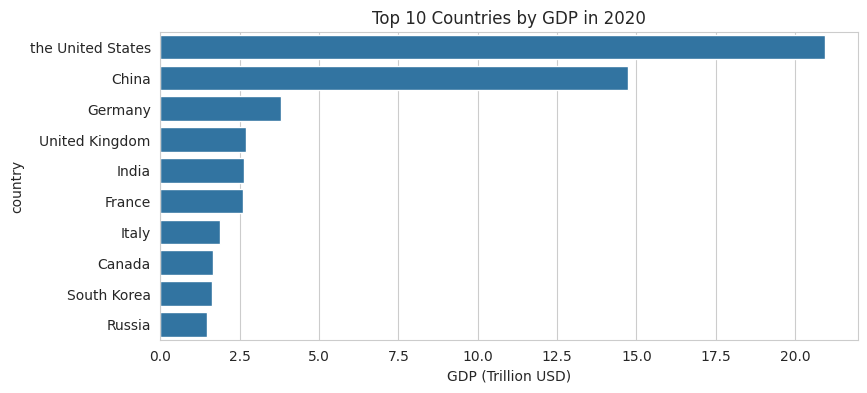

In [7]:
top_countries_2020 = df[df["year"] == 2020].sort_values("gdp", ascending=False).head(10)
plt.figure(figsize=(9, 4))
sns.barplot(x=top_countries_2020["gdp"] / 1e12, y=top_countries_2020["country"])
plt.title("Top 10 Countries by GDP in 2020")
plt.xlabel("GDP (Trillion USD)")
plt.show()

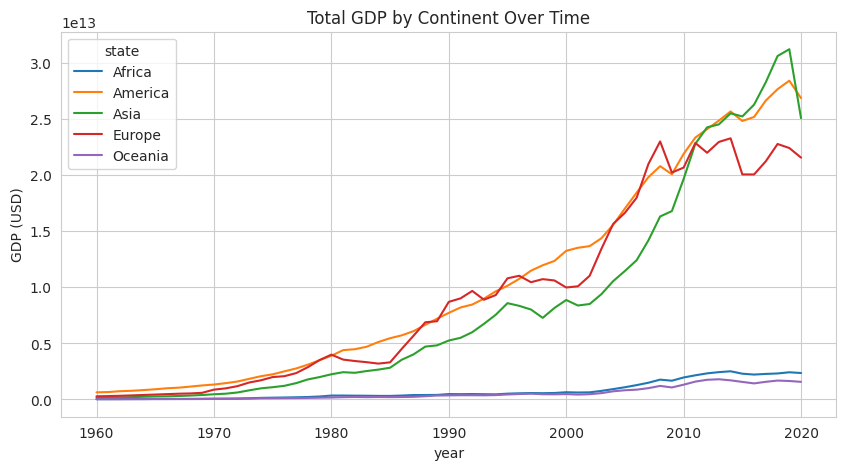

In [8]:
state_gdp = df.groupby(["year", "state"])["gdp"].sum().reset_index()
plt.figure(figsize=(10, 5))
sns.lineplot(data=state_gdp, x="year", y="gdp", hue="state")
plt.title("Total GDP by Continent Over Time")
plt.ylabel("GDP (USD)")
plt.show()

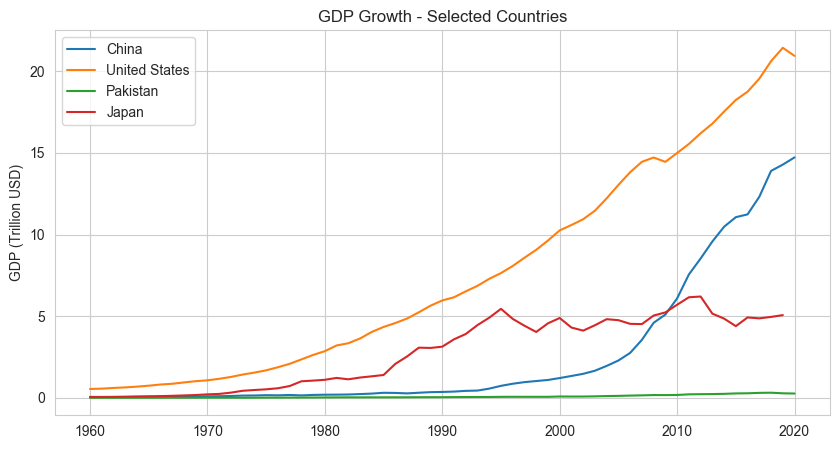

In [6]:
sample_countries = ["China", "United States", "Pakistan", "Japan"]
plt.figure(figsize=(10, 5))
for c in sample_countries:
    subset = df[df["country"].str.contains(c, case=False, na=False)]
    if len(subset) > 0:
        plt.plot(subset["year"], subset["gdp"] / 1e12, label=c)
plt.legend()
plt.title("GDP Growth - Selected Countries")
plt.ylabel("GDP (Trillion USD)")
plt.show()

## 4. Feature Engineering

All lag, rolling, and growth features use only prior-year values per country.
`country_freq` is the one exception worth flagging: counting how many rows a
country contributes and dividing by dataset length is a group-level statistic,
and if computed over the full dataset it draws on rows from the future test
period, the same class of leak as computing author or publisher frequency
before a train/test split. It is computed here strictly from the training
period once the split boundary is known, in the section below.

In [10]:
data = df.copy()
data["log_gdp"] = np.log1p(data["gdp"])

# lag features (previous 1, 2, 3 years) and rolling averages of log GDP within each country
grp = data.groupby("country")["log_gdp"]
data["lag_1"] = grp.shift(1)
data["lag_2"] = grp.shift(2)
data["lag_3"] = grp.shift(3)
data["rolling_mean_3"] = grp.shift(1).rolling(3).mean().reset_index(level=0, drop=True)
data["rolling_mean_5"] = grp.shift(1).rolling(5).mean().reset_index(level=0, drop=True)

# year-over-year growth rate, lagged, no current-year leakage
data["yoy_growth_lag_1"] = data.groupby("country")["log_gdp"].diff().shift(1)

# lagged rank and gdp_percent, using current-year values would leak since they are
# derived from the same year's gdp across all countries
data["rank_lag_1"] = data.groupby("country")["rank"].shift(1)
data["gdp_percent_lag_1"] = data.groupby("country")["gdp_percent"].shift(1)

# years since country first appears in dataset
data["years_since_start"] = data["year"] - data.groupby("country")["year"].transform("min")

# drop rows without full lag history (first 5 years per country)
required = ["lag_1", "lag_2", "lag_3", "rolling_mean_5", "yoy_growth_lag_1",
            "rank_lag_1", "gdp_percent_lag_1"]
data = data.dropna(subset=required).reset_index(drop=True)

print(data.shape)
data.head()

(8989, 16)


,year,rank,country,state,gdp,gdp_percent,log_gdp,lag_1,lag_2,lag_3,rolling_mean_3,rolling_mean_5,yoy_growth_lag_1,rank_lag_1,gdp_percent_lag_1,years_since_start
0,1965,57,Afghanistan,Asia,1006666637,0.000590,20.729910,20.500122,20.437064,20.119350,20.352179,20.256580,0.063058,65.0,0.000514,5
1,1966,53,Afghanistan,Asia,1399999966,0.000756,21.059738,20.729910,20.500122,20.437064,20.555699,20.381971,0.229788,57.0,0.000590,6
2,1967,53,Afghanistan,Asia,1673333417,0.000847,21.238084,21.059738,20.729910,20.500122,20.763257,20.569237,0.329828,53.0,0.000756,7
3,1968,61,Afghanistan,Asia,1373333366,0.000642,21.040507,21.238084,21.059738,20.729910,21.009244,20.792984,0.178345,53.0,0.000847,8
4,1969,62,Afghanistan,Asia,1408888922,0.000597,21.066067,21.040507,21.238084,21.059738,21.112776,20.913672,-0.197577,61.0,0.000642,9


## 5. Chronological Train-Test Split

The split boundary is fixed first, before `country_freq` is computed, so the
frequency statistic can be learned strictly from training rows.

In [11]:
# chronological split by year: last 15% of years held out as test set (no shuffling,
# this is time-series data, a random split would leak future information into training)
split_year = data["year"].quantile(0.85)
train_mask = data["year"] <= split_year
test_mask = data["year"] > split_year

print(f"Split year: {split_year}")
print("Train rows:", train_mask.sum(), "Test rows:", test_mask.sum())

Split year: 2014.0
Train rows: 7811 Test rows: 1178


In [12]:
# frequency-encode country (209 categories, too many for one-hot), learned from
# training rows only so no test-period presence leaks into the feature
train_country_counts = data.loc[train_mask, "country"].value_counts()
n_train = train_mask.sum()
data["country_freq"] = data["country"].map(train_country_counts).fillna(0) / n_train

feature_cols = [
    "lag_1", "lag_2", "lag_3", "rolling_mean_3", "rolling_mean_5",
    "yoy_growth_lag_1", "rank_lag_1", "gdp_percent_lag_1",
    "years_since_start", "country_freq"
]
categorical_cols = ["state"]

X = data[feature_cols + categorical_cols].copy()
y = data["log_gdp"].copy()

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
print(X.shape, y.shape)

(8989, 14) (8989,)


In [13]:
from sklearn.preprocessing import StandardScaler

X_train, X_test = X[train_mask], X[test_mask]
y_train, y_test = y[train_mask], y[test_mask]

scaler = StandardScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns, index=X_test.index)

print(X_train.shape, X_test.shape)

(7811, 14) (1178, 14)


## 6. Model Training

Panel dataset with strong lag/autocorrelation structure favors classical ML over deep learning. Training Ridge, Random Forest, XGBoost, and a Stacking Ensemble.

In [14]:
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def evaluate(model, X_te, y_te, name):
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae = mean_absolute_error(y_te, preds)
    r2 = r2_score(y_te, preds)
    print(f"{name}: RMSE={rmse:.4f} MAE={mae:.4f} R2={r2:.4f}")
    return {"model": name, "rmse": rmse, "mae": mae, "r2": r2}

results = []

In [15]:
ridge_params = {"alpha": [0.1, 1.0, 10.0]}
ridge_grid = GridSearchCV(Ridge(random_state=RANDOM_STATE), ridge_params, cv=3, scoring="r2", n_jobs=1)
ridge_grid.fit(X_train_scaled, y_train)
ridge_best = ridge_grid.best_estimator_
print("Best Ridge params:", ridge_grid.best_params_)
results.append(evaluate(ridge_best, X_test_scaled, y_test, "Ridge"))

Best Ridge params: {'alpha': 1.0}
Ridge: RMSE=0.1391 MAE=0.0883 R2=0.9965


In [16]:
rf_params = {
    "n_estimators": [100, 200],
    "max_depth": [8, 12],
}
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1),
    rf_params, cv=3, scoring="r2", n_jobs=1
)
rf_grid.fit(X_train, y_train)
rf_best = rf_grid.best_estimator_
print("Best RF params:", rf_grid.best_params_)
results.append(evaluate(rf_best, X_test, y_test, "Random Forest"))

Best RF params: {'max_depth': 8, 'n_estimators': 200}
Random Forest: RMSE=0.1508 MAE=0.0951 R2=0.9959


In [17]:
xgb_params = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1],
}
xgb_grid = GridSearchCV(
    XGBRegressor(random_state=RANDOM_STATE, n_jobs=1, verbosity=0),
    xgb_params, cv=3, scoring="r2", n_jobs=1
)
xgb_grid.fit(X_train, y_train)
xgb_best = xgb_grid.best_estimator_
print("Best XGB params:", xgb_grid.best_params_)
results.append(evaluate(xgb_best, X_test, y_test, "XGBoost"))

Best XGB params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200}
XGBoost: RMSE=0.1506 MAE=0.0969 R2=0.9959


In [18]:
stack = StackingRegressor(
    estimators=[
        ("ridge", ridge_best),
        ("rf", rf_best),
        ("xgb", xgb_best),
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=1,
    cv=3,
)
stack.fit(X_train, y_train)
results.append(evaluate(stack, X_test, y_test, "Stacking Ensemble"))

Stacking Ensemble: RMSE=0.1382 MAE=0.0877 R2=0.9966


## 7. Model Comparison

In [19]:
results_df = pd.DataFrame(results).sort_values("r2", ascending=False).reset_index(drop=True)
results_df

,model,rmse,mae,r2
0,Stacking Ensemble,0.138245,0.087747,0.996563
1,Ridge,0.139126,0.088268,0.996519
2,XGBoost,0.150562,0.096894,0.995923
3,Random Forest,0.150789,0.095098,0.995911


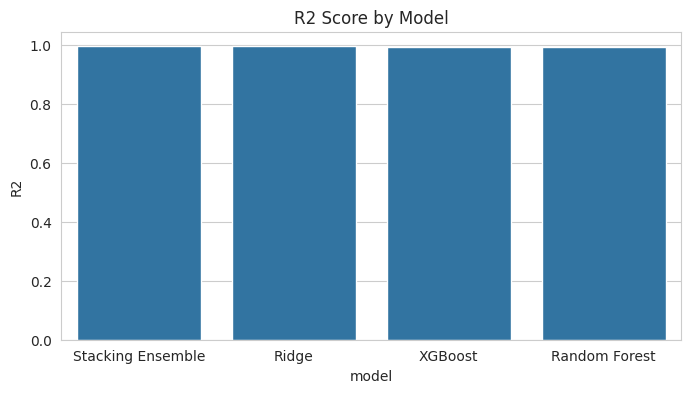

In [20]:
plt.figure(figsize=(8, 4))
sns.barplot(data=results_df, x="model", y="r2")
plt.title("R2 Score by Model")
plt.ylabel("R2")
plt.show()

## 8. Feature Importance (XGBoost)

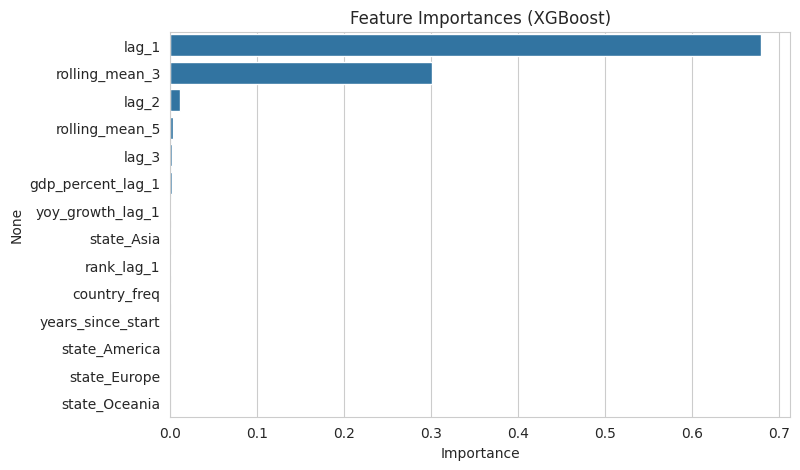

In [21]:
importances = pd.Series(xgb_best.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(8, 5))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importances (XGBoost)")
plt.xlabel("Importance")
plt.show()

## 9. Final Evaluation on Best Model

Best model: Stacking Ensemble
RMSE (log scale): 0.1382
MAE (log scale): 0.0877
R2: 0.9966


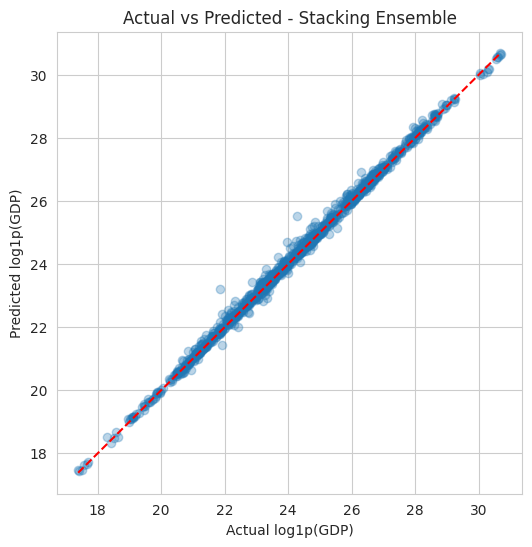

In [22]:
best_row = results_df.iloc[0]
model_map = {
    "Ridge": (ridge_best, X_test_scaled),
    "Random Forest": (rf_best, X_test),
    "XGBoost": (xgb_best, X_test),
    "Stacking Ensemble": (stack, X_test),
}
best_model, best_X_test = model_map[best_row["model"]]
preds = best_model.predict(best_X_test)

print(f"Best model: {best_row['model']}")
print(f"RMSE (log scale): {best_row['rmse']:.4f}")
print(f"MAE (log scale): {best_row['mae']:.4f}")
print(f"R2: {best_row['r2']:.4f}")

plt.figure(figsize=(6, 6))
plt.scatter(y_test, preds, alpha=0.3)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Actual log1p(GDP)")
plt.ylabel("Predicted log1p(GDP)")
plt.title(f"Actual vs Predicted - {best_row['model']}")
plt.show()